# App Functionality Demonstration

In this notebook we will be demonstrating the functionality of our proposed application.

This application is intended to be used by people to help them organize themselves

## Imports and Installs

In [21]:
import os
import sys

# Add the project root (one level up from /notebooks) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import json
import requests

import os
import cv2
import numpy as np
from PIL import Image
import torch
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    RobertaTokenizer
)
from pydantic import BaseModel, Field
from typing import List

from IPython.display import display, Markdown

from core.cv_pipeline import get_compute_device, load_trocr_model, segment_words, recognize_text_words

from core.nlp.markdown_display import display_pre_visit_agenda, display_post_visit_plan

from core.nlp.schemas import SymptomItem, PreVisitAgenda, MedicationInstruction, PostVisitPlan

from core.nlp.engine import generate_pre_visit_agenda, generate_post_visit_actions, answer_grounded_qa


## Patient Profile

### Pre Appointment

In [22]:
pre_appointment_prompt = """
I've been having trouble focusing at work and losing track of tasks for about 8 months now. 
It's gotten worse since I switched jobs in the spring. I was diagnosed with ADHD back in college and tried Ritalin for about a year, but it gave me headaches so I stopped. 
After that I was on Adderall XR 20mg for two years, which helped but made it hard to sleep, so my doctor switched me to Vyvanse 30mg about six months ago. 
I'm still having trouble concentrating even on the Vyvanse and I've been forgetting appointments and losing things more than usual. 
I want to talk about whether the dose needs adjusting or if I should try something else.
"""

In [23]:
# Now lets let the llm do its job to organize the patients throughts into organized questions

pre_appointment_response = generate_pre_visit_agenda(pre_appointment_prompt)

In [24]:
# Now lets display what the output would be to the User
display_pre_visit_agenda(pre_appointment_response)


## Pre-Visit Agenda Summary

**Chief Complaint:**  
> trouble focusing at work

---

###  Symptom Timeline
- **trouble focusing at work**: Duration not specified
- **worse focus since job switch**: Duration not specified

---

### Current Medications & Supplements
- Ritalin
- Adderall XR 20mg
- Vyvanse 30mg

---

### Prioritized Questions for the Physician
1. whether the dose needs adjusting
2. if I should try something else


Now we will expect the patient will have questions on why the LLM generated the questions they did so we added and 

In [25]:
question_1 = "Where did you find that I have been having trouble focusing at work?"

answer_grounded_qa(pre_appointment_prompt, pre_appointment_response, question_1)

'I found that you have been having trouble focusing at work in the "Original Patient Notes" section, specifically in the first paragraph:\n\n"I\'ve been having trouble focusing at work and losing track of tasks for about 8 months now."'

### Post appointment 

In [26]:
post_appointment_promt = "I have recently finished my appointment with the doctor and he gave me the follwoing notes:"

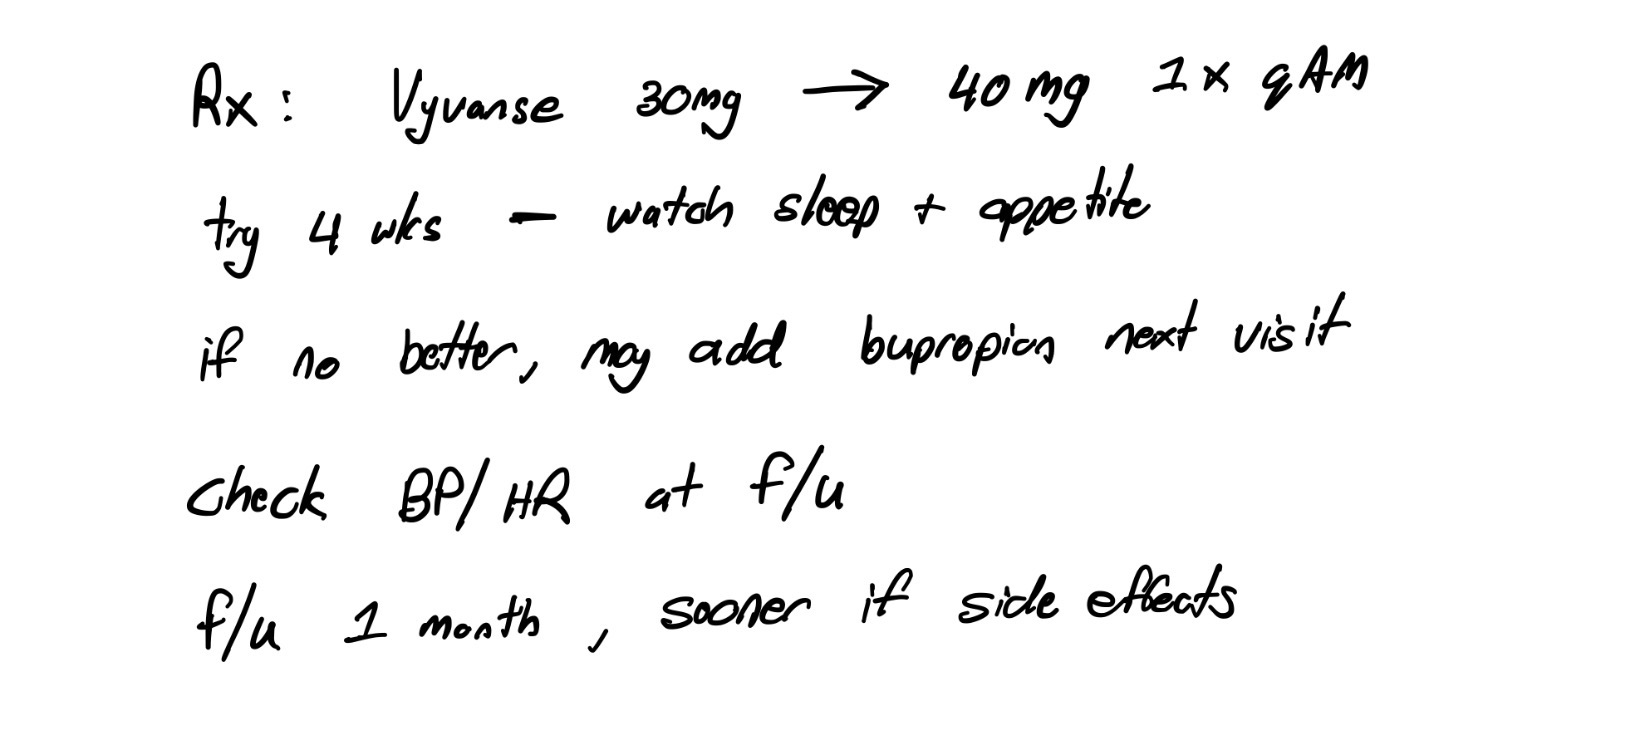

In [27]:
## Perscription given by the doctor
image_path = "../data/test_images/Doctors_shorthand.jpg"
doctors_notes_image = Image.open(image_path).convert("RGB")

display(doctors_notes_image)

In [28]:
model_path = None

# Converting perscription image into text to add extra context to the prompt

# Select compute device
device = get_compute_device()

# Load the baseline TrOCR model
model_path = "microsoft/trocr-base-handwritten"  # or pass None safely after updating cv_pipeline.py
model, processor = load_trocr_model(model_path, device)

# Segment words using OpenCV
word_crops, annotated_canvas = segment_words(doctors_notes_image)

# Recognize text (passing the device argument)
extracted_words = recognize_text_words(word_crops, model, processor, device)

# Combine into prescription context prompt
doctors_notes_prompt = " ".join(extracted_words)
print(doctors_notes_prompt)

Path 'microsoft/trocr-base-handwritten' not found. Falling back to base checkpoint...


Loading weights: 100%|██████████| 478/478 [00:00<00:00, 6700.79it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


rx sp Vyvanse 30mg 7 4,40 mg. 1 x q am . try . 4 wks . a watch . sleep . at appetite if no better . 1 . may add bupropics . next vis it . check BPI . hr. at flu. flu 1 month . soomer . it side effects I


In [29]:
final_post_appointment_prompt = post_appointment_promt + doctors_notes_prompt

print(final_post_appointment_prompt)

I have recently finished my appointment with the doctor and he gave me the follwoing notes:rx sp Vyvanse 30mg 7 4,40 mg. 1 x q am . try . 4 wks . a watch . sleep . at appetite if no better . 1 . may add bupropics . next vis it . check BPI . hr. at flu. flu 1 month . soomer . it side effects I


In [30]:
post_appointment_response = generate_post_visit_actions(final_post_appointment_prompt)

In [31]:
display_post_visit_plan(post_appointment_response)


## 🩺 Post-Visit Action Plan & Summary

### 💊 Medication Instructions
- {'name': 'Vyvanse', 'dosage': '30mg', 'instructions': '1 x q am (every 4 hours) for 4 weeks'}

---

### ✅ Patient Action Checklist
_No action items._

---

### 🚨 Warning Signs & When to Call the Clinic
_Standard clinic contact guidance applies._

---

### 🗓️ Follow-Up Schedule
> **Follow up as needed.**
